# Appendix C — Signal-to-noise of the macro inputs and the MSCI price series

Reads persisted artifacts only (offline, no DB/API):

- `data/macro_panel_monthly.parquet` — the three macro inputs (`cpi_yoy`, `t10y2y`, `hy_oas`, monthly, 2010–2026)
- `data/etf_prices_wide_2013_2026.parquet` — SWDA.L close (iShares Core **MSCI World** UCITS ETF, the world-equity sleeve and the directional-eval target), 2013–2026

**Two signal-to-noise ratios, deliberately kept apart.**

1. **Level SNR (Harvey's local-level `q`).** Model each series as a persistent level plus
   observation noise: $x_t = \mu_t + \varepsilon_t$, $\mu_t = \mu_{t-1} + \eta_t$, with
   $q = \sigma^2_\eta / \sigma^2_\varepsilon$ — the classic structural-time-series
   signal-to-noise ratio (Harvey 1989). It answers: *how measurable is the state?* Under
   this model the observed change $\Delta x_t$ is MA(1), so `q` has a closed-form moment
   estimator from the autocovariances of $\Delta x$
   ($\hat\sigma^2_\varepsilon = -\gamma_1$, $\hat\sigma^2_\eta = \gamma_0 + 2\gamma_1$,
   hence $\hat q = -\gamma_0/\gamma_1 - 2$), reported alongside the Kalman MLE as a
   cross-check. The **signal share of monthly change variance** is $q/(q+2)$.
2. **Forecast SNR.** For the one-period *changes* (macro differences, log returns):
   $|\mu|/\sigma$ and the lag-1 autocorrelation $\rho_1$ (AR(1) predictability
   $R^2 = \rho_1^2$). It answers: *how predictable is the next move?* For returns,
   $\Phi(|\mu|/\sigma)$ is the directional-accuracy ceiling of the unconditional
   drift — the number that connects to Appendix B's coin-flip result.

A series can be all signal by the first measure and all noise by the second — a random
walk is exactly that — and this distinction is the appendix's point.

## 1. Load the series

In [1]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm

warnings.filterwarnings("ignore")
from pathlib import Path
from scipy import stats

DATA = Path.cwd().parent / "data"

macro = pd.read_parquet(DATA / "macro_panel_monthly.parquet")[["cpi_yoy", "t10y2y", "hy_oas"]]
swda = pd.read_parquet(DATA / "etf_prices_wide_2013_2026.parquet")["SWDA.L"].dropna()
logpx_m = (np.log(swda.resample("ME").last().dropna()) * 100).rename("SWDA.L log px (x100)")
logpx_d = (np.log(swda) * 100).rename("SWDA.L daily log px (x100)")

SERIES = {c: macro[c] for c in macro.columns} | {"SWDA.L (log px, monthly)": logpx_m}
for name, s in SERIES.items():
    print(f"{name:26s} {s.dropna().index.min():%Y-%m} .. {s.dropna().index.max():%Y-%m}  n={s.notna().sum()}")

cpi_yoy                    2011-01 .. 2026-03  n=182
t10y2y                     2010-01 .. 2026-04  n=196
hy_oas                     2010-01 .. 2026-04  n=196
SWDA.L (log px, monthly)   2013-01 .. 2026-05  n=161


## 2. Level SNR — local-level model per series

Kalman MLE of $(\sigma^2_\eta, \sigma^2_\varepsilon)$ (missing months handled by the
state-space filter), plus the moment estimator from $\Delta x$'s autocovariances. A
non-negative $\gamma_1(\Delta x)$ means the MA(1)-implied noise variance is zero — the
moment estimate of `q` is unbounded and reported as ∞ (pure signal, random-walk-like).

In [2]:
def local_level(y):
    res = sm.tsa.UnobservedComponents(y, level="llevel").fit(disp=False)
    p = dict(zip(res.param_names, res.params))
    s2e, s2n = p["sigma2.irregular"], p["sigma2.level"]
    q = s2n / s2e if s2e > 0 else np.inf
    return res, s2n, s2e, q

def moment_q(y):
    d = y.diff().dropna()
    g0 = d.var(ddof=1)
    g1 = d.autocorr(1) * g0
    if g1 >= 0:
        return np.inf
    return max(-g0 / g1 - 2.0, 0.0)

def share(q):
    return 1.0 if np.isinf(q) else q / (q + 2)

fits, rows = {}, []
for name, s in SERIES.items():
    res, s2n, s2e, q = local_level(s)
    fits[name] = res
    qm = moment_q(s.dropna())
    rows.append({"series": name, "sigma_level": np.sqrt(s2n), "sigma_noise": np.sqrt(s2e),
                 "q_mle": q, "q_moment": qm, "signal_share_mle": share(q),
                 "signal_share_moment": share(qm)})
level_df = pd.DataFrame(rows).set_index("series")
level_df.round(4)

,sigma_level,sigma_noise,q_mle,q_moment,signal_share_mle,signal_share_moment
series,,,,,,
cpi_yoy,0.3639,0.0000,1.342722e+10,inf,1.0000,1.0000
t10y2y,0.1524,0.0000,1.178238e+09,inf,1.0000,1.0000
hy_oas,0.5337,0.0707,5.695240e+01,65.0642,0.9661,0.9702
"SWDA.L (log px, monthly)",3.4455,0.0002,4.141553e+08,10.2331,1.0000,0.8365


## 3. Forecast SNR — the one-period changes

Monthly macro differences and SWDA.L log returns (monthly and daily). For the price
series, $\Phi(|\mu|/\sigma)$ is the best unconditional directional accuracy the drift
alone supports; the realized up-month share sits next to it.

In [3]:
changes = {name: s.diff().dropna() for name, s in SERIES.items() if not name.startswith("SWDA")}
changes["SWDA.L ret (monthly)"] = (logpx_m.diff() / 100).dropna()
changes["SWDA.L ret (daily)"] = (logpx_d.diff() / 100).dropna()

rows = []
for name, d in changes.items():
    snr = abs(d.mean()) / d.std(ddof=1)
    row = {"series": name, "mean": d.mean(), "std": d.std(ddof=1), "abs_mu_over_sigma": snr,
           "rho1": d.autocorr(1), "AR1_R2": d.autocorr(1) ** 2}
    if "ret" in name:
        row["dir_ceiling_Phi"] = stats.norm.cdf(snr)
        row["realized_up_share"] = (d > 0).mean()
    rows.append(row)
fc_df = pd.DataFrame(rows).set_index("series")
fc_df.round(4)

,mean,std,abs_mu_over_sigma,rho1,AR1_R2,dir_ceiling_Phi,realized_up_share
series,,,,,,,
cpi_yoy,0.0092,0.3658,0.0251,0.4523,0.2046,NaN,NaN
t10y2y,-0.0116,0.1524,0.0761,0.1693,0.0287,NaN,NaN
hy_oas,-0.0189,0.5440,0.0347,-0.0149,0.0002,NaN,NaN
SWDA.L ret (monthly),0.0103,0.0330,0.3123,-0.0817,0.0067,0.6226,0.6438
SWDA.L ret (daily),0.0005,0.0091,0.0559,-0.0293,0.0009,0.5223,0.5428


## 4. Charts

Left: the Kalman-smoothed level through the observed points for `hy_oas` — the visible
gap between dots and line is measurement/transitory noise. Right: the same fit on the
MSCI (SWDA.L) monthly log price — the line passes through every dot: the price has
essentially **no observation noise**; all of its variance is level innovation, and that
level is a martingale. Below: the two SNRs side by side for all series.

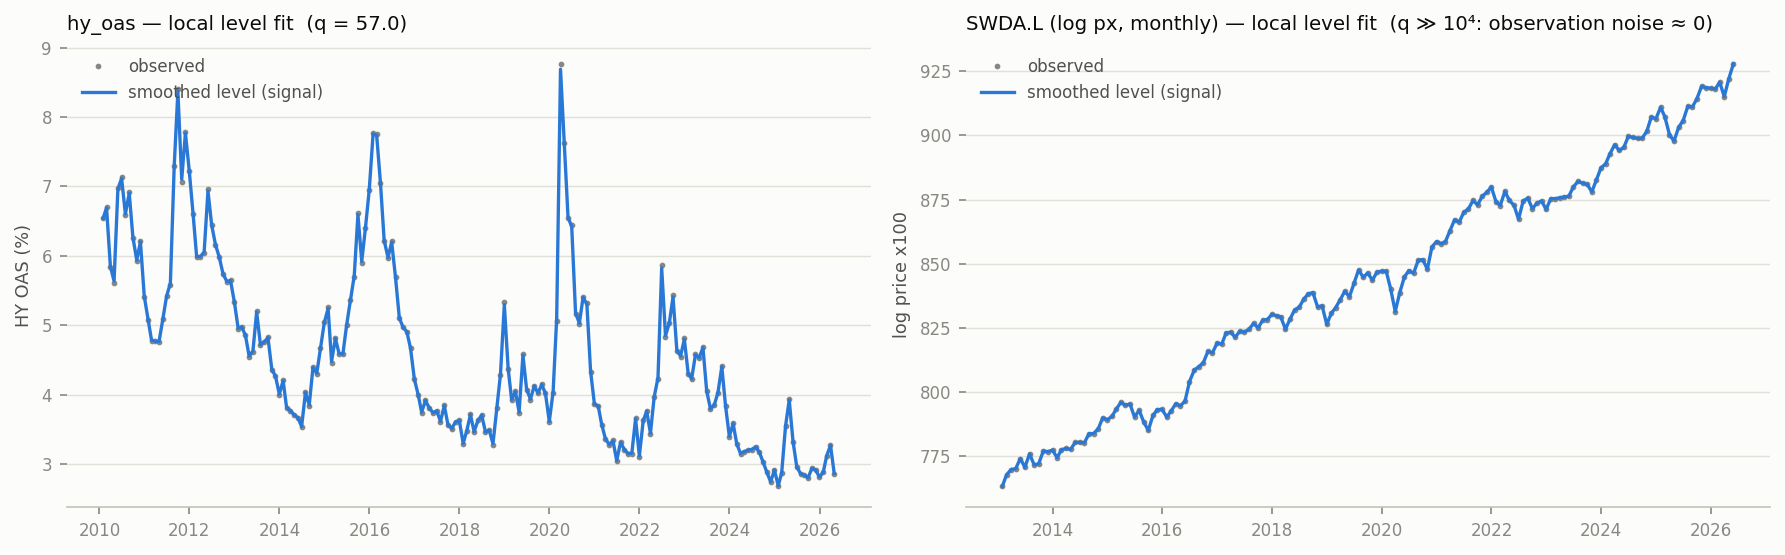

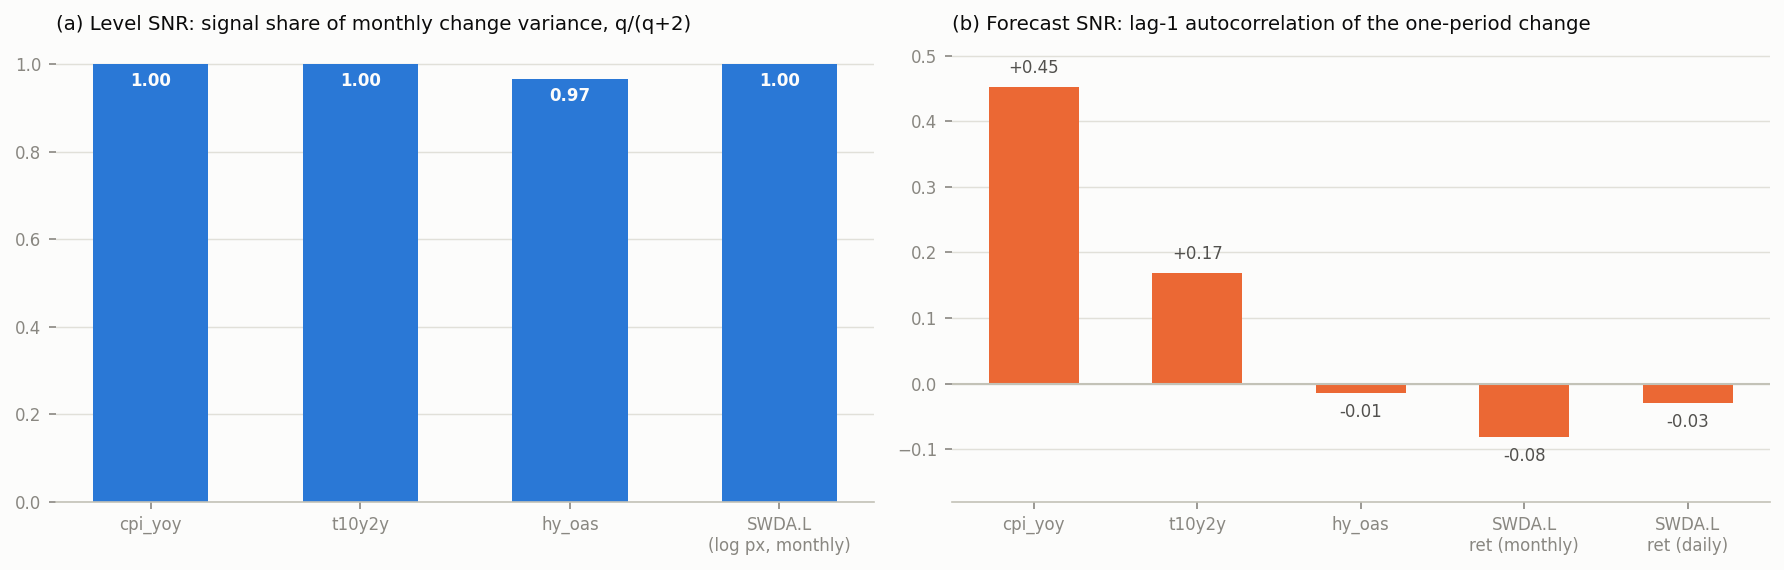

In [4]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, BLUE, ORANGE = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"

def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, lw=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=8)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.8), dpi=150)
fig.patch.set_facecolor(SURFACE)
for ax, name, ylab in [(axL, "hy_oas", "HY OAS (%)"), (axR, "SWDA.L (log px, monthly)", "log price x100")]:
    style(ax)
    s = SERIES[name]
    lvl = pd.Series(fits[name].smoothed_state[0], index=s.index)
    ax.plot(s.index, s.values, ".", color=MUTED, ms=3.5, label="observed")
    ax.plot(lvl.index, lvl.values, color=BLUE, lw=1.6, label="smoothed level (signal)")
    q = level_df.loc[name, "q_mle"]
    qtxt = f"q = {q:,.1f}" if q < 1e4 else "q ≫ 10⁴: observation noise ≈ 0"
    ax.set_title(f"{name} — local level fit  ({qtxt})", color=INK, fontsize=9.5, loc="left")
    ax.set_ylabel(ylab, color=INK2, fontsize=8.5)
    ax.legend(frameon=False, fontsize=8, labelcolor=INK2, loc="upper left")
fig.tight_layout()
plt.show()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 3.9), dpi=150)
fig.patch.set_facecolor(SURFACE)
mask = dict(facecolor=SURFACE, edgecolor="none", pad=1.2)

names = list(level_df.index)
short = [n.replace(" (log px, monthly)", "\n(log px, monthly)") for n in names]
xs = np.arange(len(names))
style(axA)
share = level_df["signal_share_mle"].values
axA.bar(xs, share, 0.55, color=BLUE)
for x, v in zip(xs, share):
    axA.text(x, v - 0.05 if v > 0.15 else v + 0.03, f"{v:.2f}",
             ha="center", color=SURFACE if v > 0.15 else INK2, fontsize=8, fontweight="bold")
axA.set_xticks(xs, short)
axA.set_ylim(0, 1.05)
axA.set_title("(a) Level SNR: signal share of monthly change variance, q/(q+2)",
              color=INK, fontsize=9.5, loc="left")

fc_names = list(changes)
fc_short = [n.replace("SWDA.L ", "SWDA.L\n") for n in fc_names]
xs = np.arange(len(fc_names))
style(axB)
rho = np.array([changes[n].autocorr(1) for n in fc_names])
axB.bar(xs, rho, 0.55, color=ORANGE)
for x, v in zip(xs, rho):
    va = "bottom" if v >= 0 else "top"
    axB.text(x, v + (0.015 if v >= 0 else -0.015), f"{v:+.2f}", ha="center", va=va,
             color=INK2, fontsize=8)
axB.axhline(0, color=BASELINE, lw=1)
axB.set_ylim(-0.18, 0.52)
axB.set_xticks(xs, fc_short)
axB.set_title("(b) Forecast SNR: lag-1 autocorrelation of the one-period change",
              color=INK, fontsize=9.5, loc="left")

fig.tight_layout()
fig.savefig(DATA / "appendix_c_signal_to_noise.png", bbox_inches="tight", facecolor=SURFACE)
plt.show()

## 5. Reading

*(numbers refer to the tables above)*

- **The macro inputs are measurable states.** All three macro series carry essentially
  all of their monthly change variance in the persistent level (signal shares 0.97–1.0):
  the state the LLM is asked to characterize (regime loadings) genuinely exists in the
  data. Their *changes* split: inflation and the curve slope trend
  ($\rho_1 = 0.45$ and $0.17$), while `hy_oas` innovations are white
  ($\rho_1 \approx 0$) — a persistent state variable, not a forecastable trend.
- **The MSCI price is all signal in the level sense — and that is precisely why it is
  unforecastable.** The local-level fit finds essentially zero observation noise: the
  price *is* its level, a martingale. The forecasting-relevant SNR of its returns is
  tiny ($|\mu|/\sigma$ per period), and $\rho_1 \approx 0$ — knowing the current
  level perfectly tells you almost nothing about next month's sign beyond the
  unconditional drift ceiling $\Phi(|\mu|/\sigma)$. (The moment estimator reads
  SWDA.L's weak negative monthly autocorrelation as a little transitory noise —
  signal share 0.84 vs the MLE's 1.0 — but that $\rho_1 = -0.08$ is statistically
  indistinguishable from zero (≈ 1.0 standard error, $n = 160$ monthly returns);
  either way the level is ≥ 84% signal.)
- **Connection to Appendix B.** This is the quantitative background for the coin-flip
  result: the pipeline's division of labor (LLM characterizes the measurable macro
  state; deterministic rules de-risk; no directional forecasting) matches where the
  signal actually lives. Directional accuracy at ≈0.5 is what a near-zero forecast SNR
  implies for any honest model, guarded or not. Chart exported to
  `data/appendix_c_signal_to_noise.png`.